SuiteSparse `.mtx` → `boruvka/graphs`, затем сводка, предобработка, бенч `boruvka_spla` / `boruvka_spark`.

In [58]:
import os, ssl, tarfile, tempfile, urllib.request
from pathlib import Path
import io

_SSL = ssl._create_unverified_context()
_CHUNK = 8 * 1024 * 1024
_TMO = 600
BASE = "https://suitesparse-collection-website.herokuapp.com/MM"
OUT = (Path("..") / "boruvka" / "graphs").resolve()
OUT.mkdir(parents=True, exist_ok=True)

# stem → (SuiteSparse group, matrix name)
GRAPHS = [
    ("amazon0601", "SNAP", "amazon0601"),
    ("citationCiteseer", "DIMACS10", "citationCiteseer"),
    # ("as-skitter", "SNAP", "as-Skitter"),  # Spark: error
    ("coPapersDBLP", "DIMACS10", "coPapersDBLP"),
    ("in-2004", "LAW", "in-2004"),
    # ("soc-LiveJournal1", "SNAP", "soc-LiveJournal1"),  # Spark: error
    ("cit-Patents", "SNAP", "cit-Patents"),
    # ("USA-road-d.USA", "DIMACS10", "road_usa"),  # Spark: timeout
    # ("delaunay_n24", "DIMACS10", "delaunay_n24"),  # Spark: timeout
    # ("kron_g500-logn21", "DIMACS10", "kron_g500-logn21"),  # Spark: timeout
    # ("europe_osm", "DIMACS10", "europe_osm"),  # Spark: timeout
    # ("uk-2002", "LAW", "uk-2002"),  # SPLA timeout
]


_n = len(GRAPHS)
for _i, (stem, grp, mtx) in enumerate(GRAPHS, 1):
    dest = OUT / f"{stem}.mtx"
    if dest.is_file():
        print(f"[{_i}/{_n}] skip {stem}")
        continue
    print(f"[{_i}/{_n}] download {stem} …")
    url = f"{BASE}/{grp}/{mtx}.tar.gz"
    with urllib.request.urlopen(url, timeout=600, context=_SSL) as r:
        data = r.read()
    with tarfile.open(fileobj=io.BytesIO(data), mode="r:gz") as tf:
        members = [m for m in tf.getmembers() if m.name.endswith(".mtx")]
        m = max(members, key=lambda x: x.size or 0)
        dest.write_bytes(tf.extractfile(m).read())
    print(f"[{_i}/{_n}] ok {stem}")

[1/5] skip amazon0601
[2/5] skip citationCiteseer
[3/5] skip coPapersDBLP
[4/5] skip in-2004
[5/5] skip cit-Patents


In [59]:
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.io import mmread, mmwrite
from scipy.sparse import coo_matrix, csgraph, issparse


def mm_hdr(path):
    hdr, n, m = None, None, None
    with open(path, encoding="latin-1", errors="replace") as f:
        for ln in f:
            s = ln.strip()
            if s.startswith("%%MatrixMarket"):
                hdr = s.split()
            elif s and not s.startswith("%"):
                n, m = map(int, s.replace(",", " ").split()[:2])
                break
    return n, m, hdr[-2].lower(), hdr[-1].lower()


def symmetrize_min(A):
    A = A.tocoo()
    n, best = A.shape[0], {}
    for i, j, v in zip(A.row, A.col, A.data):
        if i == j:
            continue
        a, b = (i, j) if i < j else (j, i)
        t = best.get((a, b))
        if t is None or v < t:
            best[(a, b)] = v
    if not best:
        return coo_matrix((n, n)).tocsr()
    rs, cs, ds = [], [], []
    for (a, b), v in best.items():
        rs += (a, b)
        cs += (b, a)
        ds += (v, v)
    return coo_matrix((ds, (rs, cs)), shape=(n, n)).tocsr()


def graph_table(stems: list[str]):
    rows = []
    for stem in stems:
        p = OUT / f"{stem}.mtx"
        n, m, fld, sym = mm_hdr(p)
        u = sym in ("symmetric", "hermitian")
        A = mmread(p).tocsr()
        A.eliminate_zeros()
        co = A.tocoo()
        r, c, d = co.row, co.col, co.data
        E = int(((r < c) | ((r == c) & (d != 0))).sum()) if u else int((d != 0).sum())
        B = A.astype(bool) if u else (A + A.T).astype(bool)
        comp = csgraph.connected_components(B, directed=False)[0]
        if fld == "pattern":
            wflag = "pattern"
        elif np.iscomplexobj(d):
            wflag = "yes" if np.all(np.real(d) >= 0) else "no"
        else:
            wflag = "yes" if np.all(d >= 0) else "no"
        rows.append(
            {
                "file": p.name,
                "kind": "undirected" if u else "directed",
                "V": n,
                "E": E,
                "components": comp,
                "nonneg_weights": wflag,
            }
        )
    return pd.DataFrame(rows)


display(graph_table([g[0] for g in GRAPHS]))

,file,kind,V,E,components,nonneg_weights
0,amazon0601.mtx,undirected,403394,2443408,7,yes
1,citationCiteseer.mtx,undirected,268495,1156647,1,yes
2,coPapersDBLP.mtx,undirected,540486,15245729,1,yes
3,in-2004.mtx,undirected,1382908,13591473,134,yes
4,cit-Patents.mtx,undirected,3774768,16518947,3627,yes


In [60]:
GRAPHS_BENCH: list[str] = []

for stem, *_ in GRAPHS:
    p = OUT / f"{stem}.mtx"
    row = graph_table([stem]).iloc[0]
    if row["nonneg_weights"] == "no":
        continue
    _, _, fld, sym = mm_hdr(p)
    undir = sym in ("symmetric", "hermitian")
    raw = mmread(p)
    co = raw.tocoo() if issparse(raw) else coo_matrix(raw)
    data = np.ones(co.nnz, np.float64) if fld == "pattern" else np.asarray(co.data, np.float64)
    A = coo_matrix((data, (co.row, co.col)), shape=co.shape).tocsr()
    A.eliminate_zeros()
    if not undir:
        A = symmetrize_min(A)
        A.eliminate_zeros()
        if A.nnz and np.any(A.data < 0):
            continue
        mmwrite(str(p), A, field="real", symmetry="symmetric")
    elif fld == "pattern":
        mmwrite(str(p), A, field="real", symmetry="symmetric")
    GRAPHS_BENCH.append(stem)

display(graph_table(GRAPHS_BENCH))

,file,kind,V,E,components,nonneg_weights
0,amazon0601.mtx,undirected,403394,2443408,7,yes
1,citationCiteseer.mtx,undirected,268495,1156647,1,yes
2,coPapersDBLP.mtx,undirected,540486,15245729,1,yes
3,in-2004.mtx,undirected,1382908,13591473,134,yes
4,cit-Patents.mtx,undirected,3774768,16518947,3627,yes


In [61]:
import os
import shlex
import subprocess
import sys
from pathlib import Path

import numpy as np
from scipy import stats

RESULTS = (Path(".") / "results").resolve()
RESULTS.mkdir(parents=True, exist_ok=True)
SPLA = (Path("..") / "boruvka" / "boruvka_spla" / "build" / "boruvka_spla").resolve()
SPARK = (Path("..") / "boruvka" / "boruvka_spark").resolve()


# For non-NaN ``time_ci95_half_ms`` in ``bench_results_table``, need N_TIMED >= 2.
N_TIMED, N_WARMUP = 20, 10
N_TOTAL_ITERS = N_TIMED + N_WARMUP
BENCH_WARMUP = 0


def _spark_cmd(mtx: Path, csv_out: Path):
    q = lambda p: shlex.quote(str(p))
    inner = f"cd {q(SPARK)} && make run GRAPH={q(mtx)} CSV={q(csv_out)} RUNS={N_TOTAL_ITERS} WARMUP={BENCH_WARMUP}"
    sh = os.environ.get("SHELL") or ("/bin/zsh" if sys.platform == "darwin" else "/bin/bash")
    fl = "-ilc" if Path(sh).name == "zsh" else "-lc"
    return [sh, fl, inner]


def _timed_slice(df: pd.DataFrame) -> pd.DataFrame:
    return df.iloc[-N_TIMED:]


def _agg_time(df: pd.DataFrame, *, ci_level: float = 0.95):
    """Mean, sample std, median, IQR over timed rows; ``n_runs``; half-width of CI for the mean (Student t)."""
    c = "time_ms"
    t = pd.to_numeric(df[c], errors="coerce").dropna()
    n = len(t)
    if n == 0:
        return float("nan"), 0.0, float("nan"), float("nan"), 0, float("nan")
    mean = float(t.mean())
    std = float(t.std(ddof=1)) if n > 1 else 0.0
    med = float(t.median())
    q1, q3 = float(t.quantile(0.25)), float(t.quantile(0.75))
    iqr = q3 - q1
    ci_half = float("nan")
    if n >= 2:
        alpha = 1.0 - ci_level
        sem = std / np.sqrt(n)
        t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
        ci_half = float(sem * t_crit)
    return mean, std, med, iqr, n, ci_half


def _mst_meta(df: pd.DataFrame):
    r = df.iloc[-1]
    w = float(r["mst_weight"])
    w = int(w) if w == int(w) else w
    return w, int(r["vertices"]), int(r["mst_edges"])


def run_bench_spla(platform: str) -> None:
    for stem in GRAPHS_BENCH:
        mtx = (OUT / f"{stem}.mtx").resolve()
        csv_out = (RESULTS / f"spla-{platform}-{stem}.csv").resolve()
        csv_out.unlink(missing_ok=True)
        env = os.environ.copy()
        cmd = [
            str(SPLA),
            "--mtxpath",
            str(mtx),
            "--out",
            str(csv_out),
            "--niters",
            str(N_TOTAL_ITERS),
            "--warmup",
            str(BENCH_WARMUP),
            "--platform",
            "1" if platform == "nvidia" else "0"
        ]
        if platform == "cpu":
            cmd.append("--cpu-only")
        subprocess.run(cmd, env=env)


def run_bench_spark(csv_prefix: str = "spark") -> None:
    for stem in GRAPHS_BENCH:
        mtx = (OUT / f"{stem}.mtx").resolve()
        csv_out = (RESULTS / f"{csv_prefix}-{stem}.csv").resolve()
        csv_out.unlink(missing_ok=True)
        csv_out.parent.mkdir(parents=True, exist_ok=True)
        r = subprocess.run(_spark_cmd(mtx, csv_out), stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        if r.returncode != 0:
            print((r.stderr or r.stdout or "").strip())


def bench_results_table(csv_prefix: str) -> pd.DataFrame:
    """Aggregate CSV files ``{csv_prefix}-{graph}.csv`` (same ``csv_prefix`` as in run_*)."""
    rows = []
    for stem in GRAPHS_BENCH:
        df = pd.read_csv(RESULTS / f"{csv_prefix}-{stem}.csv")
        timed = _timed_slice(df)
        mn, sd, med, iqr, n_runs, ci95_half = _agg_time(timed)
        mw, mv, me = _mst_meta(timed)
        rows.append(
            {
                "graph": stem,
                "library": csv_prefix.replace("-", " "),
                "time_mean_ms": mn,
                "time_std_ms": sd,
                "time_ci95_half_ms": ci95_half,
                "mst_weight": mw,
                "mst_vertices": mv,
                "mst_edges": me,
            }
        )
    return pd.DataFrame(
        rows,
        columns=[
            "graph",
            "library",
            "time_mean_ms",
            "time_std_ms",
            "time_ci95_half_ms",
            "mst_weight",
            "mst_vertices",
            "mst_edges",
        ],
    )


In [62]:
import pyopencl as cl


def print_opencl_platforms_devices():
    """GPU only (CL_DEVICE_TYPE_GPU)."""
    for pi, platform in enumerate(cl.get_platforms()):
        try:
            devices = platform.get_devices(device_type=cl.device_type.GPU)
        except cl.LogicError as e:
            print(f"Platform [{pi}] {platform.name!r} — (GPU query error: {e})")
            continue
        if not devices:
            continue
        print(f"Platform [{pi}] {platform.name!r}")
        print(f"  Vendor: {platform.vendor!r}")
        print(f"  Version: {platform.version!r}")
        for di, device in enumerate(devices):
            dtype = cl.device_type.to_string(device.type)
            print(f"  Device [{di}] {device.name!r}")
            print(f"    Type: {dtype}")
            print(f"    Vendor: {device.vendor!r}")


print_opencl_platforms_devices()


Platform [0] 'Intel(R) OpenCL Graphics'
  Vendor: 'Intel(R) Corporation'
  Version: 'OpenCL 3.0 '
  Device [0] 'Intel(R) UHD Graphics'
    Type: ALL | GPU
    Vendor: 'Intel(R) Corporation'
Platform [1] 'NVIDIA CUDA'
  Vendor: 'NVIDIA Corporation'
  Version: 'OpenCL 3.0 CUDA 13.0.97'
  Device [0] 'NVIDIA GeForce GTX 1650 Ti'
    Type: ALL | GPU
    Vendor: 'NVIDIA Corporation'


In [63]:
run_bench_spla("intel")

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) UHD Graphics vendor:intel mcu:23 wave:8 mwgs:256
env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) UHD Graphics vendor:intel mcu:23 wave:8 mwgs:256
env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) UHD Graphics vendor:intel mcu:23 wave:8 mwgs:256
env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) UHD Graphics vendor:intel mcu:23 wave:8 mwgs:256
env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) UHD Graphics vendor:intel mcu:23 wave:8 mwgs:256


In [64]:
run_bench_spla("nvidia")

env: OpenCL Acc NVIDIA CUDA device: NVIDIA GeForce GTX 1650 Ti vendor:nvidia mcu:16 wave:32 mwgs:1024
env: OpenCL Acc NVIDIA CUDA device: NVIDIA GeForce GTX 1650 Ti vendor:nvidia mcu:16 wave:32 mwgs:1024
env: OpenCL Acc NVIDIA CUDA device: NVIDIA GeForce GTX 1650 Ti vendor:nvidia mcu:16 wave:32 mwgs:1024
env: OpenCL Acc NVIDIA CUDA device: NVIDIA GeForce GTX 1650 Ti vendor:nvidia mcu:16 wave:32 mwgs:1024
env: OpenCL Acc NVIDIA CUDA device: NVIDIA GeForce GTX 1650 Ti vendor:nvidia mcu:16 wave:32 mwgs:1024


In [65]:
run_bench_spla("cpu")

env: none (accelerator disabled, force_no_acceleration, CpuCsr)
env: none (accelerator disabled, force_no_acceleration, CpuCsr)
env: none (accelerator disabled, force_no_acceleration, CpuCsr)
env: none (accelerator disabled, force_no_acceleration, CpuCsr)
env: none (accelerator disabled, force_no_acceleration, CpuCsr)


In [ ]:
run_bench_spark("spark")

In [67]:
bench_spla_p0 = bench_results_table("spla-intel")
display(bench_spla_p0)

,graph,library,time_mean_ms,time_std_ms,time_ci95_half_ms,mst_weight,mst_vertices,mst_edges
0,amazon0601,spla intel,1416.87275,17.530176,8.204375,403387,403394,403387
1,citationCiteseer,spla intel,1496.40595,57.276532,26.806242,269369,268495,269369
2,coPapersDBLP,spla intel,8629.75080,286.054730,133.877735,540511,540486,540511
3,in-2004,spla intel,26517.08460,604.542556,282.934625,1506970,1382908,1506970
4,cit-Patents,spla intel,42759.98300,1371.363081,641.817678,3856941,3774768,3856941


In [68]:
bench_spla_p1 = bench_results_table("spla-nvidia")
display(bench_spla_p1)

,graph,library,time_mean_ms,time_std_ms,time_ci95_half_ms,mst_weight,mst_vertices,mst_edges
0,amazon0601,spla nvidia,1366.07820,5.178179,2.423462,403387,403394,403387
1,citationCiteseer,spla nvidia,1424.78195,45.877498,21.471330,269540,268495,269540
2,coPapersDBLP,spla nvidia,8740.67280,339.513377,158.897152,540515,540486,540515
3,in-2004,spla nvidia,25097.21655,313.871000,146.896150,1539422,1382908,1539422
4,cit-Patents,spla nvidia,40862.06385,1102.789705,516.121469,3855241,3774768,3855241


In [69]:
bench_spla_cpu = bench_results_table("spla-cpu")
display(bench_spla_cpu)


,graph,library,time_mean_ms,time_std_ms,time_ci95_half_ms,mst_weight,mst_vertices,mst_edges
0,amazon0601,spla cpu,2444.25395,11.932797,5.584721,403387,403394,403387
1,citationCiteseer,spla cpu,4467.00370,15.024625,7.031741,269347,268495,269347
2,coPapersDBLP,spla cpu,16791.35275,63.061947,29.513900,540525,540486,540525
3,in-2004,spla cpu,76626.76370,122.731411,57.440069,1590569,1382908,1590569
4,cit-Patents,spla cpu,154179.86210,351.295916,164.411550,3858301,3774768,3858301


In [70]:
bench_spark = bench_results_table("spark")
display(bench_spark)

,graph,library,time_mean_ms,time_std_ms,time_ci95_half_ms,mst_weight,mst_vertices,mst_edges
0,amazon0601,spark,11757.6655,2283.504448,1068.712979,403387,403394,403387
1,citationCiteseer,spark,9256.6180,1530.490969,716.291822,268494,268495,268494
2,coPapersDBLP,spark,22158.8675,390.812788,182.906015,540485,540486,540485
3,in-2004,spark,52626.7850,2028.927492,949.567296,1382774,1382908,1382774
4,cit-Patents,spark,154167.3160,2710.068707,1268.351197,3771141,3774768,3771141


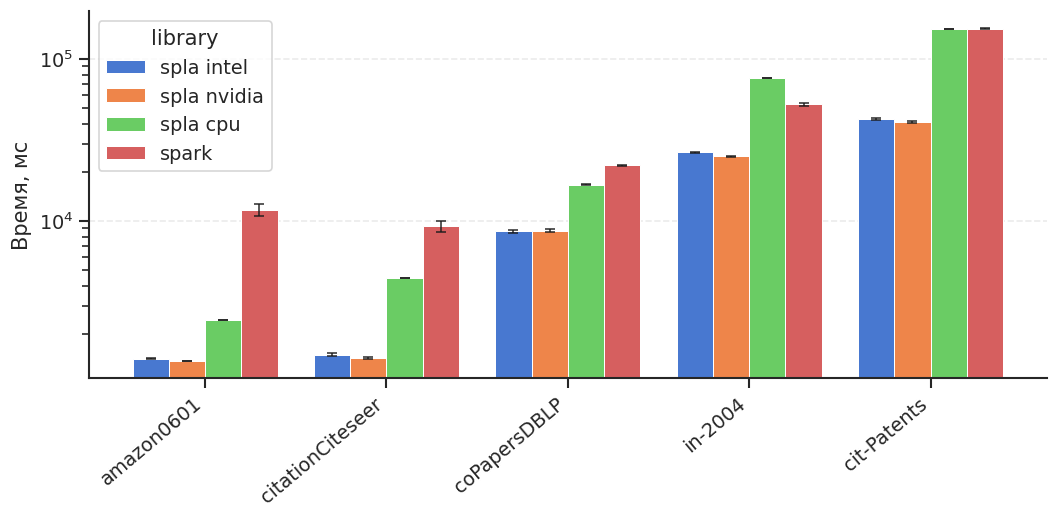

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.concat([bench_spla_p0, bench_spla_p1, bench_spla_cpu, bench_spark], ignore_index=True)
graphs = list(df["graph"].unique())
libs = list(df["library"].unique())

sns.set_theme(style="ticks", context="notebook", font_scale=1.05)
pal = sns.color_palette("muted", n_colors=len(libs))
colors = dict(zip(libs, pal))

x = np.arange(len(graphs))
w = 0.22 if len(libs) == 3 else 0.8 / len(libs)
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=120)

for i, lib in enumerate(libs):
    s = df[df["library"] == lib].set_index("graph").reindex(graphs)
    ax.bar(
        x + (i - (len(libs) - 1) / 2) * w,
        s["time_mean_ms"],
        w,
        label=lib,
        color=colors[lib],
        edgecolor="white",
        linewidth=0.6,
        yerr=s["time_ci95_half_ms"].fillna(0),
        capsize=3,
        error_kw=dict(elinewidth=1, capthick=1, alpha=0.85),
    )

ax.set_xticks(x, graphs, rotation=40, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Время, мс")
ax.set_yscale("log")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
sns.despine(ax=ax)
ax.legend(frameon=True, title="library", bbox_to_anchor=(0, 1), loc="upper left")
fig.tight_layout()
plt.show()
